# 🌳 Day 7 — Decision Trees & Ensemble Methods
### 2 Hours

---

**What you will build today:**
- Gini impurity — computed and interpreted from scratch
- Decision Trees — trained, tuned, and visualised
- Why a single tree is fragile — demonstrated with data
- Random Forest — bagging + random feature selection
- Gradient Boosting — sequential error correction
- A full model comparison pipeline on real heart disease data

**Dataset:** UCI Heart Disease — 303 patients, 13 clinical features, binary target (disease / no disease)

---
> 💡 **Key idea:** One tree is powerful but fragile. Combine many trees intelligently and you get something much stronger — this is the essence of ensemble learning.

## 🔧 Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

plt.style.use('seaborn-v0_8')
np.random.seed(42)
print('Setup complete ✅')

Setup complete ✅


---
# Part 1 — Decision Trees & Gini Impurity
## Understanding Decision Tree with Real Life Use Case

Till now we have understood about the attributes and components of decision tree. Now lets jump to a real life use case in which how decision tree works step by step.

### Step 1: Start with the Whole Dataset

We begin with all the data which is treated as the **root node** of the decision tree.

### Step 2: Choose the Best Question (Attribute)

Pick the best question to divide the dataset. For example ask: **"What is the outlook?"**

Possible answers: **Sunny**, **Cloudy** or **Rainy**.

### Step 3: Split the Data into Subsets

Divide the dataset into groups based on the question:

- If **Sunny** → go to one subset
- If **Cloudy** → go to another subset
- If **Rainy** → go to the last subset

### Step 4: Split Further if Needed (Recursive Splitting)

For each subset, ask another question to refine the groups.

For example, if the **Sunny** subset is mixed, ask: **"Is the humidity high or normal?"**

- High Humidity → **"Swimming"**
- Normal Humidity → **"Hiking"**

### Step 5: Assign Final Decisions (Leaf Nodes)

When a subset contains only one activity, stop splitting and assign it a label:

| Condition                     | Activity    |
|-------------------------------|-------------|
| Cloudy                        | Hiking      |
| Rainy                         | Stay Inside |
| Sunny + High Humidity         | Swimming    |
| Sunny + Normal Humidity       | Hiking      |

### Step 6: Use the Tree for Predictions

To predict an activity, follow the branches of the tree.

**Example:** If the outlook is **Sunny** and the humidity is **High**, follow the tree:

1. Start at **Outlook**
2. Take the branch for **Sunny**
3. Then go to **Humidity** and take the branch for **High Humidity**

**Result: "Swimming"**


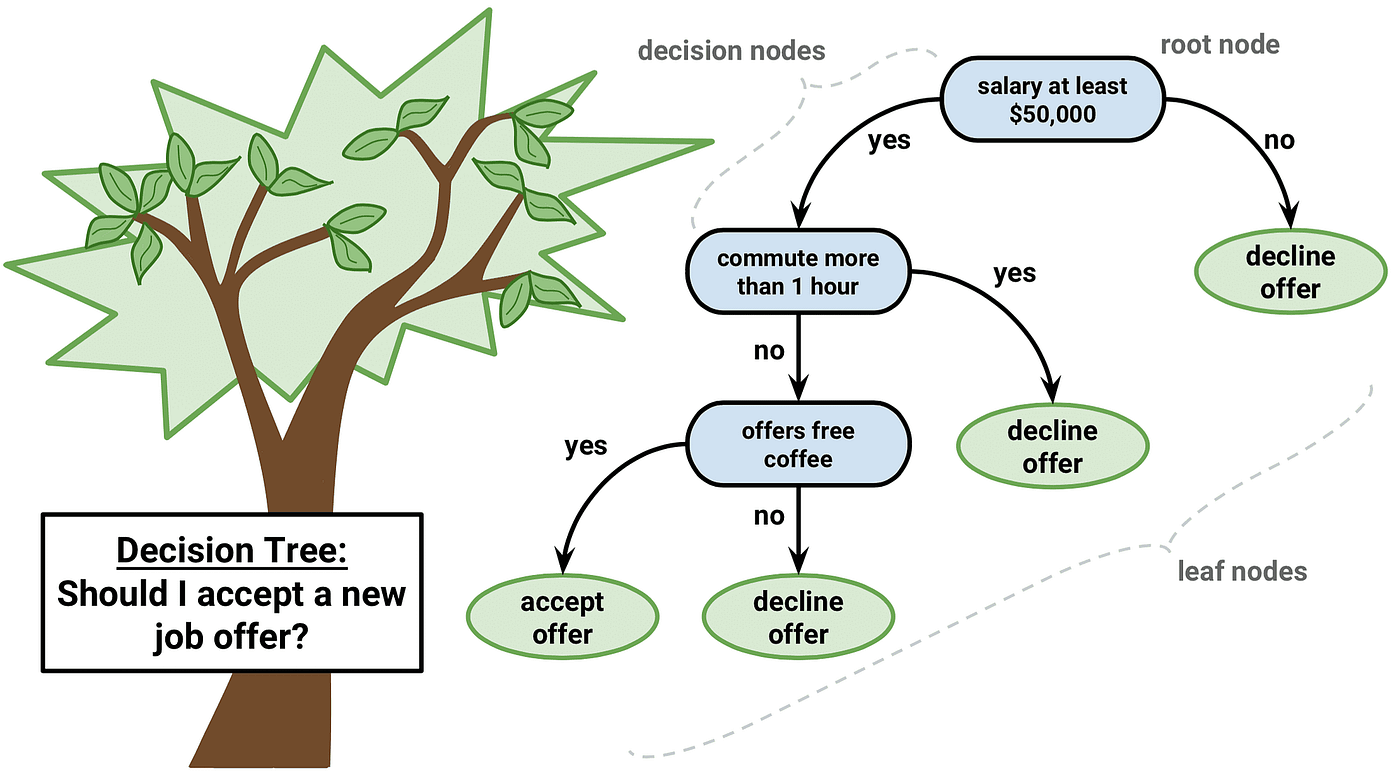

## How a Decision Tree Works

A decision tree makes predictions by asking a sequence of yes/no questions:

```
Age > 50?
    ├── Yes → Cholesterol > 240?
    │          ├── Yes → Disease ✅
    │          └── No  → No Disease ❌
    └── No  → No Disease ❌
```

At every node, the algorithm searches for the **best feature + best threshold** that splits the data into the **purest** child groups.

## Gini Impurity

Gini impurity measures how **mixed** a node is:

$$G = 1 - \sum_i p_i^2$$

where $p_i$ is the proportion of class $i$ in the node.

| Gini | Meaning |
|------|--------|
| 0.0 | Pure node — all one class |
| 0.5 | Maximum impurity — 50/50 split |

In [ ]:
# ── TASK 1 — Implement Gini Impurity ─────────────────────────────────────────
# Complete the function below.
# It takes a list of class labels (e.g. [0,0,1,1,1]) and returns the Gini score.
# Steps:
#   1. Count how many samples belong to each class
#   2. Convert counts to proportions (p_i)
#   3. Return 1 - sum(p_i²)

def gini_impurity(labels: list) -> float:
    """Compute Gini impurity for a list of class labels."""
    # YOUR CODE HERE
    pass


# Test your function on these nodes
pure_node    = [1, 1, 1, 1, 1]          # all one class
mixed_node   = [0, 0, 0, 1, 1, 1]      # perfect 50/50
partial_node = [0, 0, 0, 0, 1]         # 80/20 split

print(f'Pure node    Gini = {gini_impurity(pure_node):.3f}   (expected: 0.000)')
print(f'Mixed node   Gini = {gini_impurity(mixed_node):.3f}  (expected: 0.500)')
print(f'Partial node Gini = {gini_impurity(partial_node):.3f} (expected: 0.320)')

# 📝 What does a Gini of 0.0 mean? What about 0.5?
# ...

## Gini vs Entropy — Two Ways to Measure Impurity

Decision trees can use two different criteria to measure impurity:

| Criterion | Formula | Speed | Preferred When |
|-----------|---------|-------|----------------|
| **Gini Impurity** | $1 - \sum p_i^2$ | Faster | Default — works well in most cases |
| **Entropy (Information Gain)** | $-\sum p_i \log_2(p_i)$ | Slightly slower | When you want a more balanced tree |

In practice, the difference in accuracy is usually very small.
`sklearn` uses `criterion='gini'` by default.


In [ ]:
# ── TASK 2 — Weighted Gini after a split ─────────────────────────────────────
# When a tree splits a node into two children, the quality of the split is
# measured by the WEIGHTED average Gini of the two children:
#
#   Weighted Gini = (n_left/n_total) * G_left + (n_right/n_total) * G_right
#
# A good split produces a lower weighted Gini than the parent.
#
# Given a parent node of 10 samples [0,0,0,0,0,1,1,1,1,1] (Gini=0.5),
# evaluate which of the two splits below is better:
#
#   Split A: left=[0,0,0,0,0], right=[1,1,1,1,1]   ← clean split
#   Split B: left=[0,0,0,1,1], right=[0,1,1,1,1]   ← messy split

parent = [0, 0, 0, 0, 0, 1, 1, 1, 1, 1]

split_a_left  = [0, 0, 0, 0, 0]
split_a_right = [1, 1, 1, 1, 1]

split_b_left  = [0, 0, 0, 1, 1]
split_b_right = [0, 1, 1, 1, 1]

# YOUR CODE HERE — compute weighted Gini for split A and split B
def weighted_gini(left: list, right: list) -> float:
    """Compute weighted Gini impurity after a binary split."""
    # YOUR CODE HERE
    pass

parent_gini = gini_impurity(parent)
gini_a = weighted_gini(split_a_left, split_a_right)
gini_b = weighted_gini(split_b_left, split_b_right)

print(f'Parent Gini:         {parent_gini:.3f}')
print(f'Split A weighted:    {gini_a:.3f}  (reduction: {parent_gini - gini_a:.3f})')
print(f'Split B weighted:    {gini_b:.3f}  (reduction: {parent_gini - gini_b:.3f})')
print(f'Better split: {"A" if gini_a < gini_b else "B"}')

# 📝 The reduction in Gini is called Information Gain.
# The tree always picks the split with the HIGHEST information gain.
# ...

In [ ]:
# ── TASK 3 — Plot Gini vs class proportion ───────────────────────────────────
# For a binary classification node with p% positive samples,
# plot Gini impurity as p goes from 0% to 100%
# Mark the maximum point (p=0.5, Gini=0.5) with a red dot
# Mark the pure points (p=0, p=1) with green dots

p_vals = np.linspace(0, 1, 200)

# YOUR CODE HERE — compute Gini for each p value
gini_vals = None


fig, ax = plt.subplots(figsize=(8, 5))
# YOUR CODE HERE — plot the curve and annotations


ax.set_title('Gini Impurity vs Class Proportion (Binary Classification)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Proportion of Positive Class (p)')
ax.set_ylabel('Gini Impurity')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 📝 Why is the curve symmetric around p=0.5?
# ...

## Entropy & Information Gain

Entropy measures how **disordered or impure** a node is. It comes from information theory and answers:
> *"How much uncertainty exists in this group of labels?"*

### Formula

$$H = -\sum_{i} p_i \log_2(p_i)$$

where $p_i$ is the proportion of class $i$ in the node.

### Interpretation

| Entropy | Meaning |
|---------|---------|
| `0.0` | Pure node — all samples belong to one class |
| `1.0` | Maximum disorder — perfectly mixed (50/50 for binary) |

### Information Gain

When a node is split, **Information Gain** measures how much entropy was reduced:

$$IG = H(\text{parent}) - \left(\frac{n_{left}}{n} \cdot H_{left} + \frac{n_{right}}{n} \cdot H_{right}\right)$$

A higher Information Gain means a **better split** — the tree always picks the split that reduces entropy the most.

### Entropy vs Gini

| | Gini Impurity | Entropy |
|---|---|---|
| **Formula** | $1 - \sum p_i^2$ | $-\sum p_i \log_2(p_i)$ |
| **Range** | 0 to 0.5 | 0 to 1.0 |
| **Speed** | Faster (no log) | Slightly slower |
| **Sensitivity** | Slightly favours larger partitions | More sensitive to class distribution |
| **Default in sklearn** | Yes (`criterion='gini'`) | No (`criterion='entropy'`) |


## The Bias-Variance Tradeoff

Every machine learning model balances two sources of error:

| | Bias | Variance |
|---|---|---|
| **Definition** | Error from wrong assumptions | Error from sensitivity to training data |
| **Symptom** | Underfitting | Overfitting |
| **Example** | Tree too shallow | Tree too deep |
| **Fix** | Increase model complexity | Reduce model complexity |


Low Depth  →  High Bias,   Low Variance   (Underfitting) <br>
High Depth →  Low Bias,    High Variance  (Overfitting) <br>
Best Depth →  Balanced Bias and Variance


The goal is to find the **sweet spot** — complex enough to learn patterns, simple enough to generalise.



---
# Part 2 — Tree Depth & Overfitting

A deeper tree can ask more questions and therefore fit the training data more precisely.  
But past a certain depth it starts **memorising noise** — overfitting.

```
Depth 1  → Underfitting (too simple)
Depth 3  → Good fit
Depth 10 → Overfitting (memorises training data)
```

In [ ]:
# Load UCI Heart Disease dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
col_names = [
    'age','sex','cp','trestbps','chol','fbs','restecg',
    'thalach','exang','oldpeak','slope','ca','thal','target'
]
df = pd.read_csv(url, names=col_names, na_values='?')

# Binarise target: 0=no disease, 1=disease
df['target'] = (df['target'] > 0).astype(int)

# Drop rows with missing values
df = df.dropna()

print(f'Shape: {df.shape}')
print(f'Class balance:\n{df["target"].value_counts()}')
df.head(3)

In [ ]:
# ── TASK 4 — Data preparation ────────────────────────────────────────────────
# 1. Split X (all columns except target) and y (target)
# 2. Train/test split: 80/20, stratify=y, random_state=42
# 3. Print shapes

feature_names = col_names[:-1]

# YOUR CODE HERE
X = None
y = None


print(f'Train: {X_train.shape}  Test: {X_test.shape}')

In [ ]:
# ── TASK 5 — Depth vs accuracy experiment ────────────────────────────────────
# Train DecisionTreeClassifier for each depth in depths list
# Record train accuracy and test accuracy for each
# Plot both curves on the same axes
# Mark the "sweet spot" depth with a vertical dashed line

depths = [1, 2, 3, 4, 5, 6, 8, 10, 15, None]
depth_labels = [str(d) if d is not None else 'None' for d in depths]

train_accs = []
test_accs  = []

# YOUR CODE HERE


fig, ax = plt.subplots(figsize=(10, 5))
# YOUR CODE HERE — plot train and test accuracy curves


ax.set_title('Decision Tree: Train vs Test Accuracy by Max Depth',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Max Depth')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 📝 At what depth does the gap between train and test accuracy become large?
# What does that gap tell you?
# ...

---
# Part 3 — Tree Hyperparameters

Beyond `max_depth`, two other parameters control tree complexity:

| Parameter | What it controls |
|-----------|------------------|
| `max_depth` | How deep the tree can grow |
| `min_samples_split` | Minimum samples a node must have before it can split |
| `min_samples_leaf` | Minimum samples that must remain in each leaf node |

Higher `min_samples_split` / `min_samples_leaf` → simpler tree → less overfitting.

In [ ]:
# ── TASK 6 — Hyperparameter grid search (manual) ─────────────────────────────
# Try all combinations of the parameters below
# For each combination, record test accuracy
# Print the top 5 combinations sorted by test accuracy

param_grid = {
    'max_depth':        [3, 5, 7],
    'min_samples_split':[2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

results = []  # list of dicts: {'max_depth':..., 'min_samples_split':..., 'min_samples_leaf':..., 'accuracy':...}

# YOUR CODE HERE — nested loops over param_grid


results_df = pd.DataFrame(results).sort_values('accuracy', ascending=False)
print('Top 5 hyperparameter combinations:')
print(results_df.head(5).to_string(index=False))

# Save the best parameters for later use
best_params = results_df.iloc[0].to_dict()
print(f'\nBest: {best_params}')

---
# Part 4 — Visualising a Decision Tree

One advantage of decision trees over most models: **you can read exactly what the model learned**.  
Every node shows the splitting rule, the Gini impurity, the sample count, and the predicted class.

In [ ]:
# ── TASK 7 — Train and visualise a shallow tree ──────────────────────────────
# 1. Train DecisionTreeClassifier with max_depth=3, random_state=42
# 2. Plot it using plot_tree() with:
#    filled=True, feature_names=feature_names,
#    class_names=['No Disease','Disease'], rounded=True, fontsize=9
# 3. Use figsize=(20, 8)

# YOUR CODE HERE


# 📝 Read the top split (root node):
# - Which feature does the tree split on first?
# - What is the threshold?
# - What is the Gini impurity of the root node?
# ...

In [ ]:
# ── TASK 8 — Read the tree programmatically ──────────────────────────────────
# Print the top 3 most important features according to feature_importances_
# from your depth-3 tree above
# Plot them as a horizontal bar chart

# YOUR CODE HERE


# 📝 Does the most important feature match the root split in the visualisation?
# ...

---
# Part 5 — Why a Single Tree is Fragile

Decision trees have **high variance** — small changes to the training data can produce a very different tree, and therefore very different predictions.

We will demonstrate this directly.

In [ ]:
# ── TASK 9 — Demonstrate tree instability ────────────────────────────────────
# Train 10 different decision trees, each on a slightly different
# bootstrap sample of the training data (sample with replacement)
# For each tree, record its test accuracy
# Plot the 10 accuracies as a bar chart
# Print the standard deviation of the accuracies

n_trees = 10
tree_accs = []

for i in range(n_trees):
    # Bootstrap sample: sample len(X_train) rows WITH replacement
    # YOUR CODE HERE
    pass


fig, ax = plt.subplots(figsize=(9, 4))
# YOUR CODE HERE — plot accuracies as bars, add a mean line


ax.set_title('Single Tree Accuracy on 10 Different Bootstrap Samples',
             fontweight='bold')
ax.set_xlabel('Tree #')
ax.set_ylabel('Test Accuracy')
ax.set_ylim(0.5, 1.0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Mean accuracy:  {np.mean(tree_accs):.3f}')
print(f'Std deviation:  {np.std(tree_accs):.3f}')

# 📝 How much does accuracy vary across the 10 trees?
# Why is high variance in a model a problem in practice?
# ...

## Why Does Averaging Predictions Work? — The Crowd Wisdom Analogy

Imagine you ask **one expert** to guess the number of jellybeans in a jar.
They might be off by a lot — one person's bias or bad day affects the whole answer.

Now imagine you ask **100 different people** and average their guesses.
Individual errors cancel out. The average is usually much closer to the truth.

This is exactly what **Bagging** does with decision trees:
- Each tree is trained on a slightly different sample → makes slightly different errors
- Errors are **random and uncorrelated** → they cancel when averaged
- The ensemble is **more stable** than any single tree

> Key insight: Averaging works well only when errors are **independent**. If all trees make the same mistake, averaging does not help — this is why random feature selection in Random Forest is so important.


---
# Part 6 — Bagging (Bootstrap Aggregating)

**Idea:** If one tree trained on one sample is unstable, train many trees on many different samples and **average their predictions**.

```
Dataset
   ↓
Bootstrap Sample 1 → Tree 1 → Prediction 1
Bootstrap Sample 2 → Tree 2 → Prediction 2
         ...                      ...
Bootstrap Sample N → Tree N → Prediction N
                                    ↓
                          Majority Vote → Final Prediction
```

Each tree sees a different view of the data.  
Errors that one tree makes are unlikely to be made by all trees.  
Averaging cancels out individual errors → **lower variance**.

In [ ]:
# ── TASK 10 — Manual bagging (majority vote) ─────────────────────────────────
# 1. Train 10 decision trees, each on a different bootstrap sample
# 2. Collect each tree's predictions on X_test
# 3. Combine by majority vote: for each test sample, the final prediction
#    is whichever class the majority of trees predicted
# 4. Compute and print the bagged accuracy
# 5. Compare with the mean single-tree accuracy from Task 9

all_predictions = []  # shape will be (n_trees, n_test_samples)

for i in range(10):
    # Bootstrap sample
    idx = np.random.choice(len(X_train), size=len(X_train), replace=True)
    X_boot, y_boot = X_train[idx], y_train[idx]
    # YOUR CODE HERE — train tree, predict on X_test, append to all_predictions
    pass

all_predictions = np.array(all_predictions)  # shape: (10, n_test)

# Majority vote: for each column (test sample), pick the most common prediction
# YOUR CODE HERE
bagged_preds = None

bagged_acc = accuracy_score(y_test, bagged_preds)
print(f'Mean single tree accuracy: {np.mean(tree_accs):.3f}')
print(f'Manual bagging accuracy:   {bagged_acc:.3f}')

# 📝 Is the bagged accuracy higher than the average single tree?
# Why does combining predictions reduce variance?
# ...

---
# Part 7 — Random Forest

Random Forest = Bagging + one extra twist: at each split, only a **random subset of features** is considered.

```
Plain Bagging:    each tree uses ALL features at every split
Random Forest:    each tree uses √(n_features) random features at every split
```

**Why does random feature selection help?**  
Without it, all trees tend to split on the same dominant features → trees are correlated → averaging correlated predictions doesn't reduce variance much.  
With random features → trees are more diverse → averaging works much better.

In [ ]:
# ── TASK 11 — n_estimators effect ────────────────────────────────────────────
# Train RandomForestClassifier for each n_estimators value
# Record test accuracy for each
# Plot accuracy vs n_estimators
# At what point does adding more trees stop helping?

n_estimator_vals = [1, 5, 10, 20, 50, 100, 200, 500]
rf_accs = []

# YOUR CODE HERE
for n in n_estimator_vals:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    acc  = accuracy_score(y_test, rf.predict(X_test))
    rf_accs.append(acc)

fig, ax = plt.subplots(figsize=(9, 5))
# YOUR CODE HERE — plot the curve

ax.plot(n_estimator_vals, rf_accs, marker='o')

ax.set_title('Random Forest: Accuracy vs Number of Trees', fontweight='bold')
ax.set_xlabel('n_estimators')
ax.set_ylabel('Test Accuracy')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 📝 Why does accuracy plateau after a certain number of trees?
# What happens to training TIME as n_estimators increases?
# ...

In [ ]:
# ── TASK 12 — Train final Random Forest ──────────────────────────────────────
# Train RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
# Print accuracy, and classification report
# Compare with the single best decision tree from Task 6

# YOUR CODE HERE


# 📝 How much better is Random Forest vs the single tree?
# ...

## Gradient Boosting — Learning from Mistakes, Step by Step

Think of it like a student correcting an exam:

1. **Attempt 1:** Answer the question → some answers are wrong
2. **Attempt 2:** Focus only on the wrong answers → correct some
3. **Attempt 3:** Focus on what is still wrong → correct more
4. **Final answer:** Combine all attempts → much better overall

Each new tree in Gradient Boosting is trained **only on the residual errors** of all previous trees combined. This is called **sequential error correction**.

**Key parameters to understand:**

| Parameter | Effect |
|-----------|--------|
| `n_estimators` | How many trees (correction rounds) |
| `learning_rate` | How much to trust each tree's correction (lower = more cautious) |
| `max_depth` | How complex each individual correction tree is |

> Rule of thumb: Lower `learning_rate` + More `n_estimators` → better accuracy but slower training.


---
# Part 8 — Gradient Boosting

Boosting is a **different philosophy** from bagging:

```
Bagging:   Build trees IN PARALLEL on random samples → average
Boosting:  Build trees IN SEQUENCE, each fixing previous mistakes
```

**How Gradient Boosting works:**
1. Train Tree 1 on the data
2. Compute the **residual errors** (where Tree 1 was wrong)
3. Train Tree 2 to predict those residual errors
4. Add Tree 2's predictions to Tree 1's predictions
5. Repeat — each tree corrects what all previous trees got wrong

Final prediction = sum of all trees' contributions

**Result:** Very high predictive accuracy — often the best-performing algorithm on tabular data.

In [ ]:
# ── TASK 13 — Train Gradient Boosting ────────────────────────────────────────
# Train GradientBoostingClassifier(
#     n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42
# )
# Print accuracy and classification report

# YOUR CODE HERE


# 📝 What does learning_rate control in Gradient Boosting?
# Hint: think about how much each new tree's correction is "trusted"
# ...

In [ ]:
# ── TASK 14 — Learning rate effect in Gradient Boosting ──────────────────────
# Train GradientBoostingClassifier for each learning_rate below (n_estimators=100)
# Record test accuracy for each
# Plot: learning_rate (x-axis) vs accuracy (y-axis)

learning_rates = [0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
gb_lr_accs = []

# YOUR CODE HERE


fig, ax = plt.subplots(figsize=(9, 5))
# YOUR CODE HERE


ax.set_title('Gradient Boosting: Accuracy vs Learning Rate', fontweight='bold')
ax.set_xlabel('Learning Rate')
ax.set_ylabel('Test Accuracy')
ax.set_xscale('log')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 📝 What happens with a very high learning rate (lr=1.0)?
# What happens with a very low one (lr=0.001)?
# ...

---
# Part 9 — Full Model Comparison

Now compare all three models side by side using a complete set of metrics.

In [ ]:
# ── TASK 15 — Full metric comparison table ───────────────────────────────────
# For each model: DecisionTree (best params from Task 6), RandomForest, GradientBoosting
# Compute: Accuracy, Precision, Recall, F1, ROC-AUC
# Build a summary DataFrame and print it
#
# Hint: use average='binary' for precision/recall/f1
#       use predict_proba()[:,1] for roc_auc_score

models = {
    'Decision Tree':       DecisionTreeClassifier(
                               max_depth=int(best_params['max_depth']),
                               min_samples_split=int(best_params['min_samples_split']),
                               min_samples_leaf=int(best_params['min_samples_leaf']),
                               random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                                      max_depth=3, random_state=42),
}

comparison_rows = []

for name, model in models.items():
    # YOUR CODE HERE — fit, predict, compute all metrics
    pass

comparison_df = pd.DataFrame(comparison_rows).set_index('Model')
print('=== MODEL COMPARISON ===')
print(comparison_df.round(3).to_string())

# 📝 Which model wins on each metric?
# Is there any metric where the simple decision tree beats the ensembles?
# ...

In [ ]:
# ── TASK 16 — 5-Fold Cross Validation ───────────────────────────────────────
# Run cross_val_score(cv=5, scoring='accuracy') for all three models
# For each model print: Mean ± Std
# Plot a box plot showing the score distributions side by side

# YOUR CODE HERE


# 📝 Which model has the lowest standard deviation across folds?
# Why does low std matter in addition to high mean?
# ...

In [ ]:
# ── TASK 17 — ROC curves for all three models on one plot ────────────────────
# Plot all three ROC curves on the same axes
# Each curve labelled with model name and AUC score
# Add the diagonal baseline (random classifier)

fig, ax = plt.subplots(figsize=(7, 6))

colours = ['#2196F3', '#4CAF50', '#FF5722']

# YOUR CODE HERE


ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random (AUC=0.5)')
ax.set_title('ROC Curves — All Models', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
# Part 10 — Feature Importance

Tree-based models tell you how much each feature contributed to predictions.  
**Feature importance** = total reduction in Gini impurity caused by splits on that feature, averaged across all trees.

A high importance score means the model relied heavily on that feature.  
A near-zero score means the feature had almost no predictive value.

In [ ]:
# ── TASK 18 — Feature importance comparison ──────────────────────────────────
# Plot feature importances for all three models as horizontal bar charts
# Arrange them as 3 subplots side by side (1×3 grid, figsize=(18,6))
# Sort features by importance (most important at top)
# Use a different colour per model

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colours_fi = ['#2196F3', '#4CAF50', '#FF5722']

# YOUR CODE HERE


plt.suptitle('Feature Importance — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 📝 Do all three models agree on the most important feature?
# Are there features that one model considers important but another ignores?
# ...

## Choosing the Right Model — Quick Guide

| Situation | Recommended Model |
|-----------|------------------|
| Need to explain the decision to a non-technical audience | Decision Tree (shallow) |
| Need high accuracy, data is tabular | Random Forest or Gradient Boosting |
| Training speed matters most | Random Forest (parallelisable) |
| Maximum accuracy is the priority | Gradient Boosting |
| Dataset is small (< 1000 rows) | Decision Tree or Random Forest |
| Features have many missing values | Gradient Boosting (handles it well) |

> There is no universally best model. Always compare using cross-validation on your specific dataset.


---
# 📝 Day 7 Summary

| Concept | Key Takeaway |
|---------|-------------|
| **Gini Impurity** | Measures node mixedness — 0 = pure, 0.5 = maximum mix |
| **Decision Tree** | Splits data recursively to maximise purity at each node |
| **Overfitting** | Deep trees memorise training data — use max_depth to control |
| **High Variance** | Small data changes → very different tree → unreliable predictions |
| **Bagging** | Train many trees on bootstrap samples, combine by voting |
| **Random Forest** | Bagging + random feature subset at each split → less correlated trees |
| **Gradient Boosting** | Sequential trees, each correcting previous errors |
| **Feature Importance** | Total Gini reduction — tells you which features the model relied on |

---
# 🏠 Homework

1. Train Decision Trees with `max_depth` from 1 to 20. Plot train and validation accuracy. Identify the exact depth where overfitting begins.

2. Train a Random Forest and a Gradient Boosting model. Compare their confusion matrices side by side. Which model makes fewer false negatives (missed disease cases)?

3. Run 5-fold cross-validation for all three models. Plot the results as a box plot. Report Mean ± Std for each.

4. Take the top 5 features from the Random Forest importance plot. Look up what each clinical feature represents. Write 2–3 sentences explaining why the most important feature makes medical sense.

5. In your own words (3–5 sentences each): explain the difference between Bagging and Boosting, and explain why Random Forest usually outperforms a single Decision Tree.